# Hierarchical (Agglomerative) Clustering on Customer Credit Card Data
This notebook fits an Agglomerative Clustering model, generates a dendrogram, trains a KNN classifier proxy to predict clusters for new data points, and saves the final pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
import joblib


In [2]:
df = pd.read_csv('CC GENERAL.csv')
X = df.drop(columns=['CUST_ID'])

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_scaled = preprocessor.fit_transform(X)


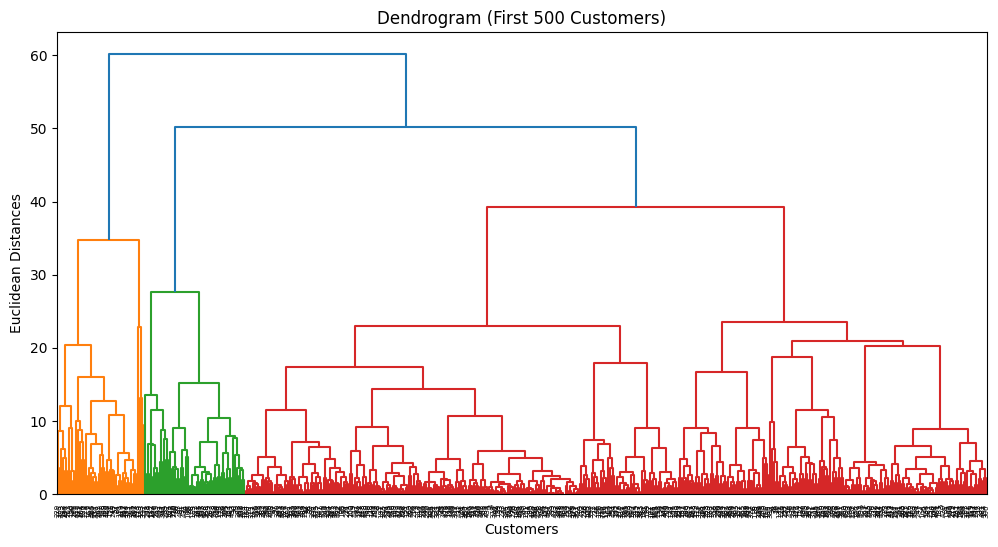

In [3]:
# Generate and Save Dendrogram (using first 500 samples for readability)
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled[:500], method='ward'))
plt.title('Dendrogram (First 500 Customers)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Fit Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels = hc.fit_predict(X_scaled)

# Train KNN Classifier Proxy because Agglomerative Clustering has no predict() method
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_scaled, cluster_labels)

# Final pipeline
hierarchical_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', knn_classifier)
])
joblib.dump(hierarchical_pipeline, 'hierarchical_model.pkl')
print('Hierarchical Clustering Proxy Pipeline saved successfully!')


Hierarchical Clustering Proxy Pipeline saved successfully!
